In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, auc, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')


In [2]:
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_labels.csv').values.ravel()
print(f"Loaded data: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Class distribution:")
print(f"  Normal (0): {(y == 0).sum():,} ({(y == 0).mean():.1%})")
print(f"  Anomaly (1): {(y == 1).sum():,} ({(y == 1).mean():.1%})")

Loaded data: 10000 samples, 28 features
Class distribution:
  Normal (0): 5,000 (50.0%)
  Anomaly (1): 5,000 (50.0%)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train anomaly ratio: {y_train.mean():.2%}")
print(f"Test anomaly ratio: {y_test.mean():.2%}")



Train set: 8000 samples
Test set: 2000 samples
Train anomaly ratio: 50.00%
Test anomaly ratio: 50.00%


In [4]:
print("\n" + "="*60)
print("DECISION TREE CLASSIFIER")
print("="*60)

# Hyperparameter tuning
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), 
                       dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)

print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best cross-validation F1: {dt_grid.best_score_:.4f}")

# Best model
dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test)
dt_pred_proba = dt_best.predict_proba(X_test)[:, 1]

# Metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print(f"\nTest Set Performance:")
print(f"  Accuracy:  {dt_accuracy:.4f}")
print(f"  Precision: {dt_precision:.4f}")
print(f"  Recall:    {dt_recall:.4f}")
print(f"  F1-Score:  {dt_f1:.4f}")


DECISION TREE CLASSIFIER
Best parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validation F1: 0.8402

Test Set Performance:
  Accuracy:  0.8580
  Precision: 0.8833
  Recall:    0.8250
  F1-Score:  0.8532


In [5]:
print("\n" + "="*60)
print("NAIVE BAYES CLASSIFIER")
print("="*60)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_pred_proba = nb_model.predict_proba(X_test)[:, 1]

# Metrics
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print(f"Test Set Performance:")
print(f"  Accuracy:  {nb_accuracy:.4f}")
print(f"  Precision: {nb_precision:.4f}")
print(f"  Recall:    {nb_recall:.4f}")
print(f"  F1-Score:  {nb_f1:.4f}")


NAIVE BAYES CLASSIFIER
Test Set Performance:
  Accuracy:  0.6335
  Precision: 0.6512
  Recall:    0.5750
  F1-Score:  0.6107


In [6]:
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER")
print("="*60)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                       rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best cross-validation F1: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_pred_proba = rf_best.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"\nTest Set Performance:")
print(f"  Accuracy:  {rf_accuracy:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall:    {rf_recall:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")



RANDOM FOREST CLASSIFIER
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validation F1: 0.8562

Test Set Performance:
  Accuracy:  0.8590
  Precision: 0.8693
  Recall:    0.8450
  F1-Score:  0.8570



MODEL COMPARISON
        Model  Accuracy  Precision  Recall  F1-Score
Decision Tree    0.8580   0.883298   0.825  0.853154
  Naive Bayes    0.6335   0.651189   0.575  0.610728
Random Forest    0.8590   0.869342   0.845  0.856998


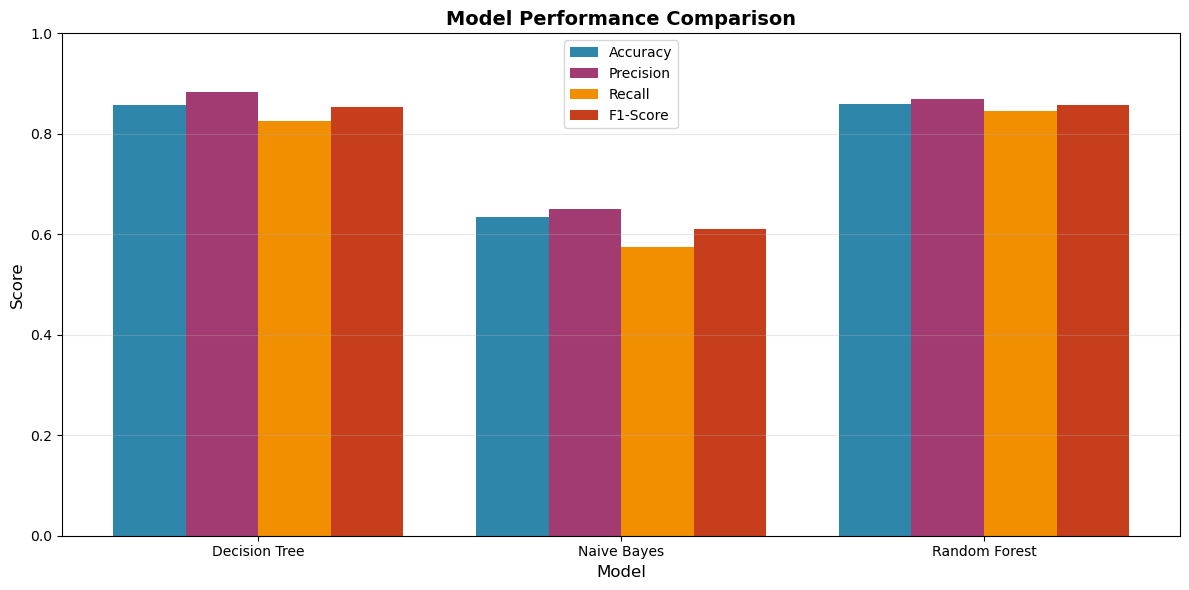

In [7]:
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [dt_accuracy, nb_accuracy, rf_accuracy],
    'Precision': [dt_precision, nb_precision, rf_precision],
    'Recall': [dt_recall, nb_recall, rf_recall],
    'F1-Score': [dt_f1, nb_f1, rf_f1]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.2

bars1 = ax.bar(x - width*1.5, comparison_df['Accuracy'], width, label='Accuracy', color='#2E86AB')
bars2 = ax.bar(x - width/2, comparison_df['Precision'], width, label='Precision', color='#A23B72')
bars3 = ax.bar(x + width/2, comparison_df['Recall'], width, label='Recall', color='#F18F01')
bars4 = ax.bar(x + width*1.5, comparison_df['F1-Score'], width, label='F1-Score', color='#C73E1D')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150)
plt.show()


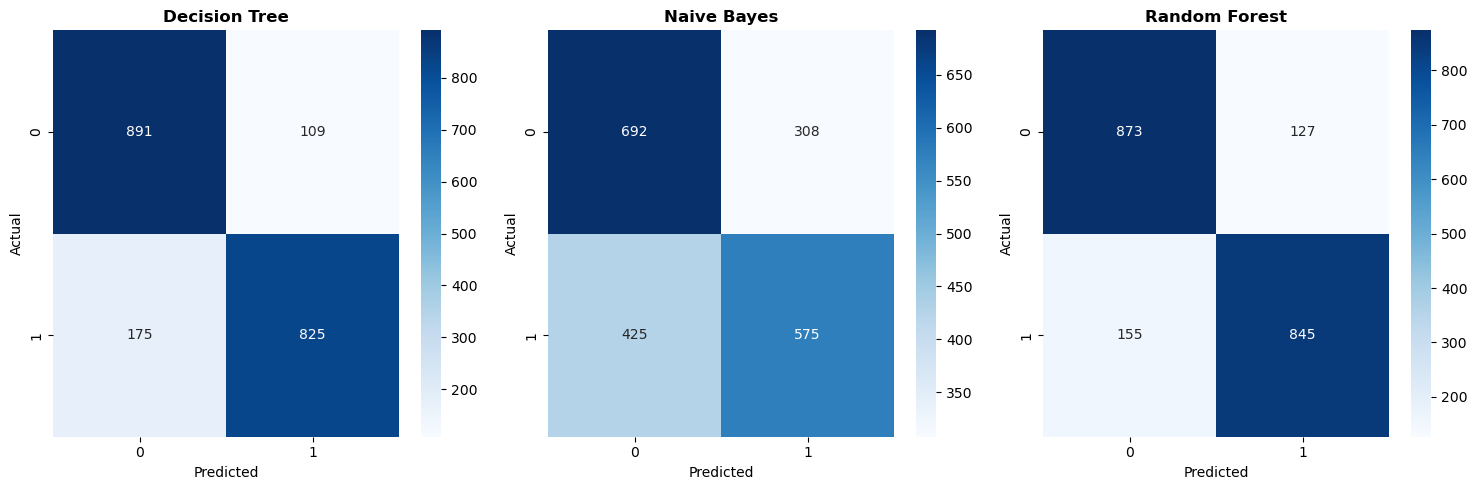

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [('Decision Tree', dt_pred), ('Naive Bayes', nb_pred), ('Random Forest', rf_pred)]
for idx, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices.png', dpi=150)
plt.show()


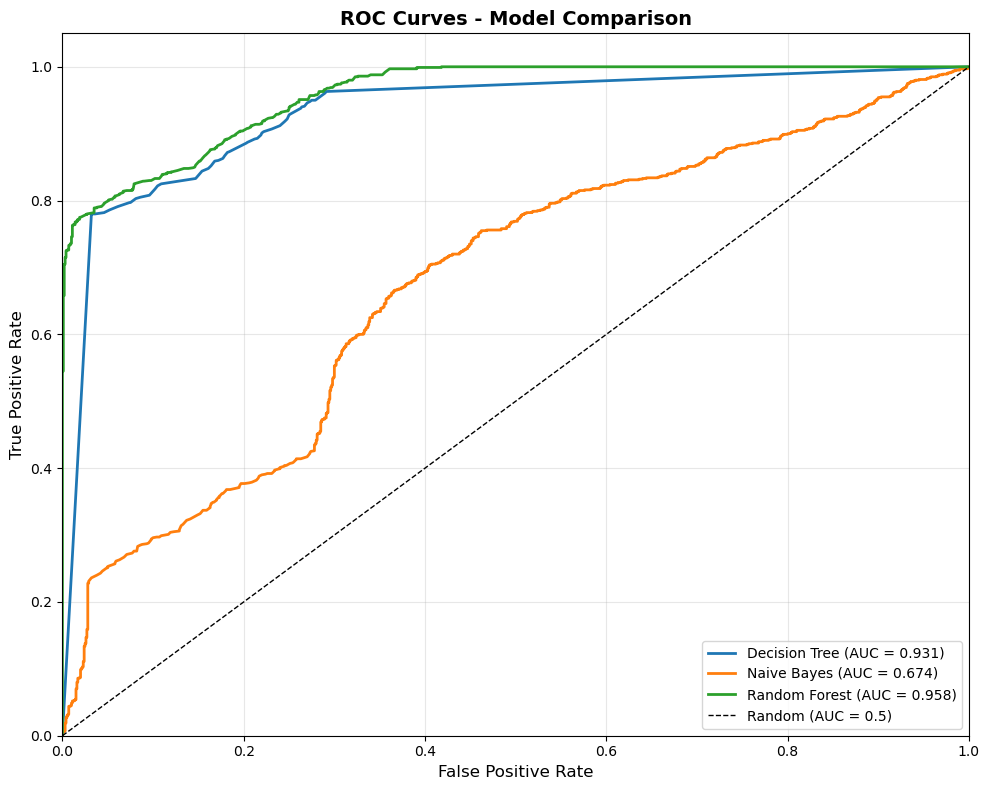

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

# ROC for each model
models_roc = [
    ('Decision Tree', dt_pred_proba),
    ('Naive Bayes', nb_pred_proba),
    ('Random Forest', rf_pred_proba)
]

for name, pred_proba in models_roc:
    fpr, tpr, _ = roc_curve(y_test, pred_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Random line
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/roc_curves.png', dpi=150)
plt.show()



Top 10 Most Important Features:
          feature  importance
      load_factor    0.168194
      night_ratio    0.112389
night_consumption    0.072439
consumption_range    0.063624
  max_consumption    0.058808
     morning_peak    0.049869
rolling_7day_mean    0.047949
  std_consumption    0.046160
     evening_peak    0.042340
  zero_proportion    0.041784


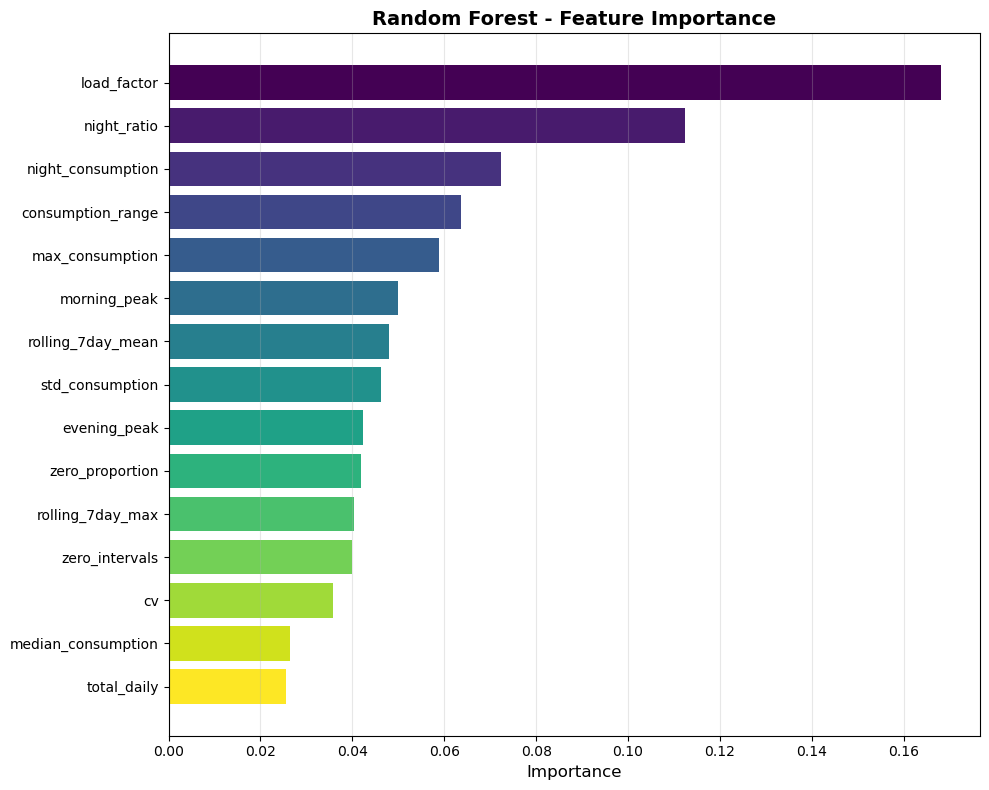

In [10]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = ax.barh(range(len(top_features)), top_features['importance'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150)
plt.show()

In [11]:
import joblib

# Save best models (Random Forest performed best)
joblib.dump(dt_best, '../data/models/decision_tree.pkl')
joblib.dump(nb_model, '../data/models/naive_bayes.pkl')
joblib.dump(rf_best, '../data/models/random_forest.pkl')

print("\n Classification models saved!")
print("Models saved:")
print("  - decision_tree.pkl")
print("  - naive_bayes.pkl")
print("  - random_forest.pkl")

# Save final model selection (Random Forest)
print(f"\nRecommended Model: Random Forest")
print(f"  Test Accuracy: {rf_accuracy:.2%}")
print(f"  Test Precision: {rf_precision:.2%}")
print(f"  Test Recall: {rf_recall:.2%}")
print(f"  Test F1-Score: {rf_f1:.2%}")


 Classification models saved!
Models saved:
  - decision_tree.pkl
  - naive_bayes.pkl
  - random_forest.pkl

Recommended Model: Random Forest
  Test Accuracy: 85.90%
  Test Precision: 86.93%
  Test Recall: 84.50%
  Test F1-Score: 85.70%
